In [69]:
import pandas as pd
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings

# Importing the libraries
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.feature_extraction import DictVectorizer

from sklearn.metrics import mean_squared_error

#show all columns in the dataframe
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")

## Q1. Downloading the data

We'll use [the same NYC taxi dataset](https://www1.nyc.gov/site/tlc/about/tlc-trip-record-data.page),
but instead of "**Green** Taxi Trip Records", we'll use "**Yellow** Taxi Trip Records".

Download the data for January and February 2023.

#### Read the data for January. How many columns are there?

* 16
* 17
* 18
* 19

In [70]:
# https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet
# https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet

# Download The data is in parquet format for January and February 2023 and save it in data folder
#!wget -O data/yellow_tripdata_2023-01.parquet https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet
#!wget -O data/yellow_tripdata_2023-02.parquet https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet

In [71]:
# load the data
df1 = pd.read_parquet('data/yellow_tripdata_2023-01.parquet')
df2 = pd.read_parquet('data/yellow_tripdata_2023-02.parquet')

In [72]:
print(df1.columns)
print(len(df1.columns))

df1.head()

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')
19


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


## Q2. Computing duration

Now let's compute the duration variable. It should contain the duration of a ride in minutes.

#### What's the standard deviation of the trips duration in January?

* 32.59
* 42.59
* 52.59
* 62.59

In [73]:
df1['duration'] = (df1['tpep_dropoff_datetime'] - df1['tpep_pickup_datetime']).dt.total_seconds()
df2['duration'] = (df2['tpep_dropoff_datetime'] - df2['tpep_pickup_datetime']).dt.total_seconds()

df1['duration'] = df1['duration'] / 60
df2['duration'] = df2['duration'] / 60

# get std value for duration column
std = df1['duration'].std()
print(std)

42.59435124195458


## Q3. Dropping outliers

Next, we need to check the distribution of the duration variable. There are some outliers. Let's remove them and keep only the records where the duration was between 1 and 60 minutes (inclusive).

#### What fraction of the records left after you dropped the outliers?

* 90%
* 92%
* 95%
* 98%

In [74]:
# checking for outliers in duration
df1_cleaned = df1[(df1.duration >= 1) & (df1.duration <= 60)]
df2_cleaned = df2[(df2.duration >= 1) & (df2.duration <= 60)]

# how many rows were removed
rows_removed = df1.shape[0] - df1_cleaned.shape[0]
print(rows_removed)

# percentage of rows removed
percentage_removed = (rows_removed / df1.shape[0]) * 100
print(f"Percentage of rows removed {percentage_removed:.2f}%")

# percentage of row remaining
percentage_remaining = 100 - percentage_removed
print(f"Percentage of rows remaining {percentage_remaining:.2f}%")

57593
Percentage of rows removed 1.88%
Percentage of rows remaining 98.12%


## Q4. One-hot encoding

Let's apply one-hot encoding to the pickup and dropoff location IDs. We'll use only these two features for our model.

* Turn the dataframe into a list of dictionaries (remember to re-cast the ids to strings - otherwise it will label encode them)
* Fit a dictionary vectorizer
* Get a feature matrix from it

#### What's the dimensionality of this matrix (number of columns)?

* 2
* 155
* 345
* 515
* 715

In [75]:
df1_cleaned[['PULocationID','DOLocationID']].describe()

,PULocationID,DOLocationID
count,3.009173e+06,3.009173e+06
mean,1.666243e+02,1.645131e+02
std,6.424609e+01,6.989129e+01
min,1.000000e+00,1.000000e+00
25%,1.320000e+02,1.140000e+02
50%,1.620000e+02,1.620000e+02
75%,2.340000e+02,2.340000e+02
max,2.650000e+02,2.650000e+02


In [76]:
# transform into categorical
categorial_cols = ['PULocationID','DOLocationID']

# convert int to object
df1_cleaned[categorial_cols] = df1_cleaned[categorial_cols].astype(str)
df2_cleaned[categorial_cols] = df2_cleaned[categorial_cols].astype(str)

In [77]:
print(f"Nº of unique values {df1_cleaned['PULocationID'].nunique() + df1_cleaned['DOLocationID'].nunique()}")

dv = DictVectorizer()

df_train_dict = df1_cleaned[categorial_cols].to_dict(orient='records')
df_val_dict = df2_cleaned[categorial_cols].to_dict(orient='records')

Nº of unique values 515


## Q5. Training a model

Now let's use the feature matrix from the previous step to train a model.

* Train a plain linear regression model with default parameters
* Calculate the RMSE of the model on the training data

#### What's the RMSE on train?

* 3.64
* 7.64
* 11.64
* 16.64

In [80]:
# transform the train data
X_train = dv.fit_transform(df_train_dict)
y_train = df1_cleaned['duration']

# transform the validation data
X_val = dv.transform(df_val_dict)
y_val = df2_cleaned['duration']

In [83]:
X_train

<3009173x515 sparse matrix of type '<class 'numpy.float64'>'
	with 6018346 stored elements in Compressed Sparse Row format>

In [82]:
#feature names
dv.feature_names_[:5]

['DOLocationID=1',
 'DOLocationID=10',
 'DOLocationID=100',
 'DOLocationID=101',
 'DOLocationID=102']

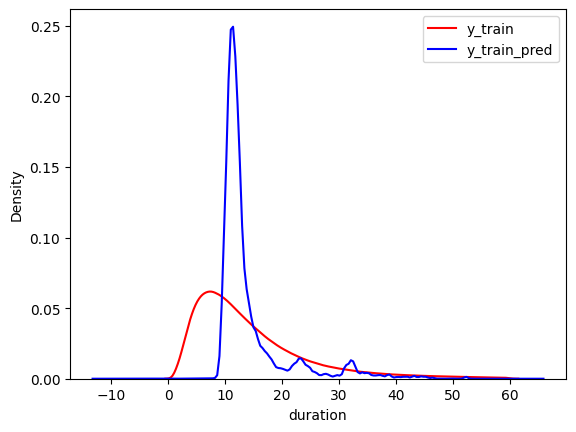

In [85]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# RMSE on training set
y_train_pred = lr.predict(X_train)

# plot density distribution of y_train and y_train_pred
sns.kdeplot(y_train, color='r', label='y_train')
sns.kdeplot(y_train_pred, color='b', label='y_train_pred')
plt.legend()

In [86]:
mean_squared_error(y_train, y_train_pred, squared=False)

7.649262029221019

## Q6. Evaluating the model

Now let's apply this model to the validation dataset (February 2023).

#### What's the RMSE on validation?

* 3.81
* 7.81
* 11.81
* 16.81


In [87]:
y_val_pred = lr.predict(X_val)

mean_squared_error(y_val, y_val_pred, squared=False)

7.8118169669491095